In [32]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 
import time
from memory_profiler import memory_usage

### Part 1

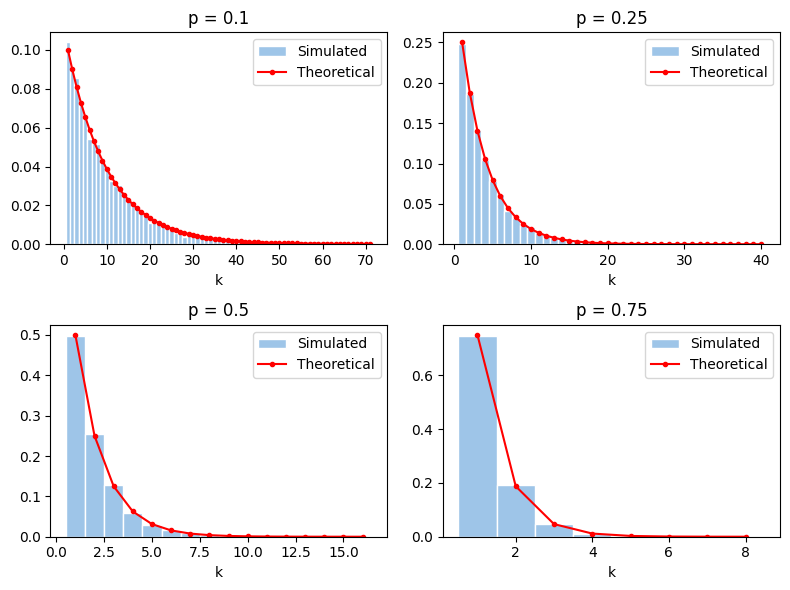

In [33]:

N = 10_000
ps = [0.1, 0.25, 0.5, 0.75]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for ax, p in zip(axes.ravel(), ps):
    U = np.random.uniform(0, 1, N)
    X = np.floor(np.log(U) / np.log(1 - p)) + 1

    ks = np.arange(1, X.max() + 1)
    theo = (1 - p) ** (ks - 1) * p

    ax.hist(X, bins=np.arange(0.5, X.max() + 1.5), density=True,
            color="#9ec5e8", edgecolor="white", label="Simulated")
    ax.plot(ks, theo, "r-o", markersize=3, label="Theoretical")
    ax.set_title(f"p = {p}")
    ax.set_xlabel("k")
    ax.legend()

fig.tight_layout()
plt.show()

### Part 2

In [34]:
xi = np.array([1,2,3,4,5,6])
pi = np.array([7/48,5/48,1/8,1/16,1/4,5/16])

### Direct method

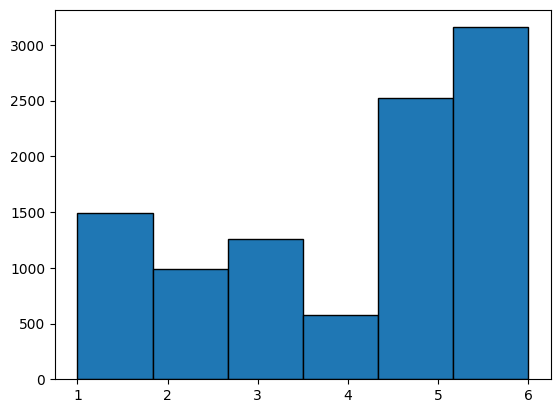

In [50]:
def direct_method(xi,pi,N):
    Pi = np.cumsum(pi)

    U = np.random.uniform(low=0,high=1,size=N)

    xi = np.asarray(xi)
    X_direct = xi[np.searchsorted(Pi, U)]

    return X_direct

np.random.seed(30)
counts_direct,_,_= plt.hist(direct_method(xi,pi,N),bins=6,edgecolor = 'black')

### Rejection method

In [51]:

def rejection_method(xi, pi, N, c= np.max(pi)+1):
    k = len(xi)
    arr = np.zeros(N)
    for i in range(N):
        acc = False
        while not acc:
            U1 = np.random.uniform(0, 1)
            I = int(np.floor(k * U1)) 
            U2 = np.random.uniform(0, 1)
            if U2 <= pi[I] / c:
                arr[i] = xi[I]
                acc=  True
                
    return arr

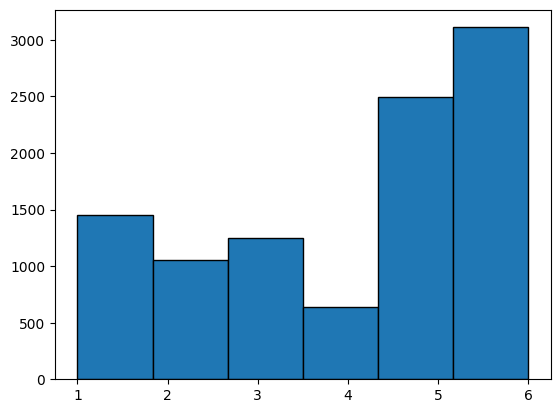

In [52]:
np.random.seed(30)
arr= rejection_method(xi,pi,N)

counts_rej,_,_= plt.hist(arr,bins=6,edgecolor = 'black')

### Alias method 

In [54]:
def generate_alias(xi, pi,eps=1e-9):
    k = len(xi)
    
    F = k * np.array(pi)
    L = np.arange(k) 
    G = list(np.where(F >= 1)[0])  
    S = list(np.where(F <= 1)[0])   
    while len(S) > 0:
        i = G[0]                          
        j = S[0]
        L[j] = i                          
        F[i] = F[i] - (1 - F[j])
        if F[i] < 1 - eps:             
            G.pop(0)
            S.append(i)
        S.pop(0)                          
    
    return L, F

def alias_generate_number(xi,pi,N):
    

    L,F= generate_alias(xi,pi)

    k = len(xi)
    arr = np.zeros(N)
    for i in range(N):
        U1 = np.random.uniform(0, 1)
        I = int(np.floor(k * U1)) 
        U2 = np.random.uniform(0, 1)
        if U2 <= F[I]:
            arr[i] = xi[I]
        else: arr[i] = xi[L[I]]
                
    return arr

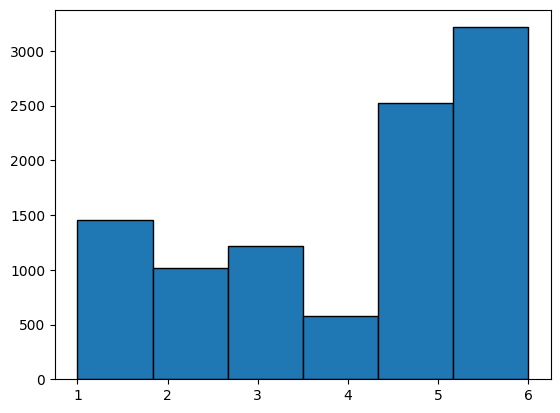

In [55]:
np.random.seed(30)
values= alias_generate_number(xi,pi,N)

counts_alias,_,_= plt.hist(values,bins=6,edgecolor = 'black')

### Part 3

### Test function

In [43]:
def chisq_test_pi(counts,pi,N):
    T = 0
    n_classes = len(counts)
    n_expected = N*pi
    
    for i in range(n_classes):
        n_observed = counts[i]
        T += (n_observed-n_expected[i])**2 / n_expected[i]
    
    p_val = 1-ss.chi2.cdf(T,df=n_classes-1)
    return p_val

In [ ]:
def benchmark(xi,pi,N,function):
    n_runs = 500
    times = 0

    for _ in range(n_runs):
        start = time.perf_counter()
        function(xi,pi,N)
        times += (time.perf_counter() - start)

    
    mem_usage = memory_usage((function, (xi, pi, N), {}))
    return times/n_runs,mem_usage[0]


In [ ]:
xi = np.array([1, 2, 3, 4, 5, 6])
pi = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
N = 200
k = len(xi)

def to_counts(samples, xi):
    return np.array([np.sum(np.asarray(samples) == v) for v in xi])

n_runs = 10000
results = {"direct": [], "rejection": [], "alias": []}

for r in range(n_runs):
    s_direct = direct_method(xi, pi, N)
    s_rej    = rejection_method(xi, pi, N)
    s_alias  = alias_generate_number(xi, pi, N)

    results["direct"].append(chisq_test_pi(to_counts(s_direct, xi), pi, N))
    results["rejection"].append(chisq_test_pi(to_counts(s_rej, xi), pi, N))
    results["alias"].append(chisq_test_pi(to_counts(s_alias, xi), pi, N))


In [79]:

average_time_alias,mem_alias = benchmark(xi,pi,N,alias_generate_number)
average_time_rej,mem_rej = benchmark(xi,pi,N,rejection_method)
average_time_direct,mem_direct = benchmark(xi,pi,N,direct_method)

In [82]:
average_time_direct,average_time_rej,average_time_alias

(2.4025199585594238e-05, 0.024925818400457503, 0.0034063536992762237)

In [83]:
mem_alias,mem_rej,mem_direct

(67.25390625, 67.265625, 67.328125)

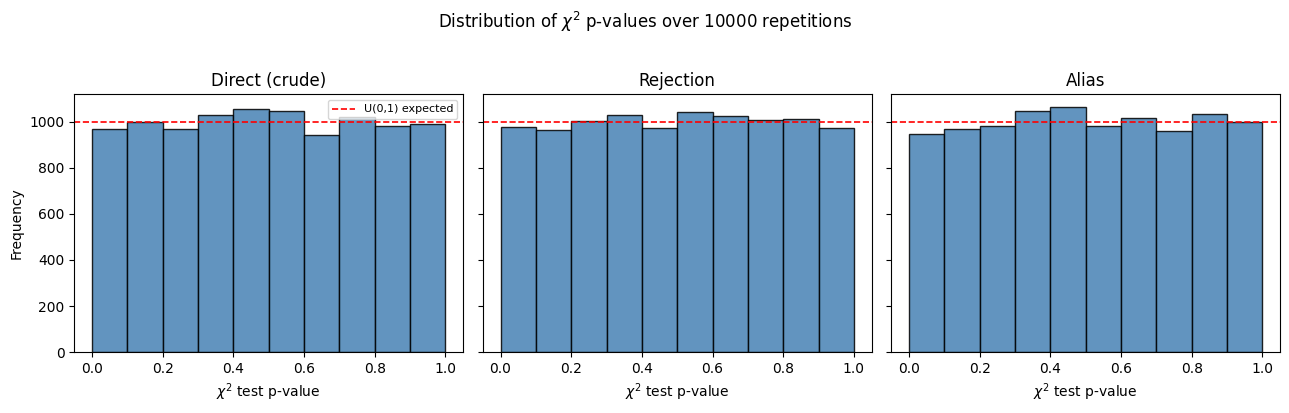

In [ ]:
methods = ["direct", "rejection", "alias"]
titles  = ["Direct (crude)", "Rejection", "Alias"]
n_bins  = 10
n_runs  = len(results["direct"])
expected = n_runs / n_bins        
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)

for ax, m, t in zip(axes, methods, titles):
    pvals = np.asarray(results[m])
    ax.hist(pvals, bins=n_bins, range=(0, 1),
            edgecolor="black", color="steelblue", alpha=0.85)
    ax.axhline(expected, color="red", ls="--", lw=1.2, label="U(0,1) expected")

    ax.set_title(f"{t}")
    ax.set_xlabel("$\\chi^2$ test p-value")

axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=8)
fig.suptitle(f"Distribution of $\\chi^2$ p-values over {n_runs} repetitions", y=1.02)
fig.tight_layout()
plt.show()